<a href="https://colab.research.google.com/github/ridhimagupta28/friendly-potato/blob/main/Stock_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Stock Market Analysis**

**Overview**: The project involves a quantitative analysis and probabilistic risk modeling of equity portfolios.
This research project carries out a detailed statistical analysis of high-growth technology equities, namely Apple, Google, Microsoft, and Amazon, for assessing market dynamics and risk exposure. This study goes beyond merely descriptive historical analysis to the implementation of predictive frameworks based on stochastic modeling.


Key Research Questions:

1. Temporal price dynamics: The process of analyzing price fluctuations over an extended period of time in order to identify significant price trends and shifts.
2. Statistical return profiles: Quantification of the mean daily returns and the characteristics of asset distribution.
3. Volatility & smoothing: Leveraging moving averages to filter raw signals from stochastic noise.
Volatility & smoothing: Leveraging moving averages
4. Inter-asset dependencies: Calculating the Pearson correlation matrices for closing prices and daily log returns to measure co-movements at the sector level.
5. Risk quantification: Developing and executing Value at Risk (VaR) techniques to identify possible capital loss thresholds based on established levels of certainty.
6. Predictive inference: Through the use of Monte Carlo methods of simulation and the moving average framework for forecasting price trends of the future.

In [1]:
import pandas as pd
from pandas import Series, DataFrame
import numpy as np

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

In [20]:
from pandas_datareader import data as pdr
from datetime import datetime
from __future__ import division
import yfinance as yf

In [14]:
tech_list=['AAPL','GOOG','MSFT','AMZN']

In [15]:
end = datetime.now()
start = datetime(end.year-1,end.month,end.day)

In [21]:
for stock in tech_list:
    globals()[stock] = yf.download(stock, start, end)

/tmp/ipython-input-2406771750.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2406771750.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2406771750.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2406771750.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


In [25]:
GOOG.describe()


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,219.025173,221.604245,216.242813,218.867030,2.380484e+07
std,57.196568,57.811377,56.618536,57.251613,1.022021e+07
min,146.177917,150.645619,142.268675,142.996668,6.138200e+06
25%,171.530190,174.186295,168.840569,171.400483,1.780810e+07
50%,196.305786,197.899562,194.166661,195.996832,2.126480e+07
75%,254.349045,257.212171,252.253415,254.953655,2.606345e+07
max,336.429993,341.200012,334.350006,338.054993,7.872980e+07


In [26]:
AAPL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-01-23 to 2026-01-22
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   251 non-null    float64
 1   (High, AAPL)    251 non-null    float64
 2   (Low, AAPL)     251 non-null    float64
 3   (Open, AAPL)    251 non-null    float64
 4   (Volume, AAPL)  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


<Axes: xlabel='Date'>

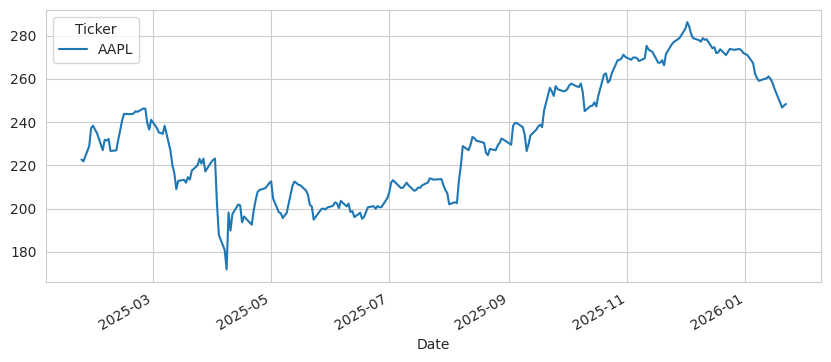

In [28]:
AAPL['Close'].plot(legend=True,figsize=(10,4))

The above image provides a visual representation of the closing price for one year's worth of Apple stock. Also it answers tge question of change in stock's price over time.

<Axes: xlabel='Date'>

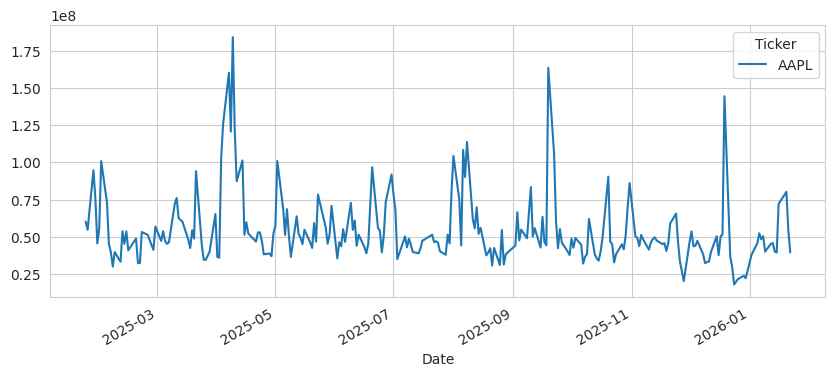

In [29]:
AAPL['Volume'].plot(legend=True, figsize=(10,4))

The above image provides a visual representation of the volume traded each day in the previous year

<Axes: xlabel='Date'>

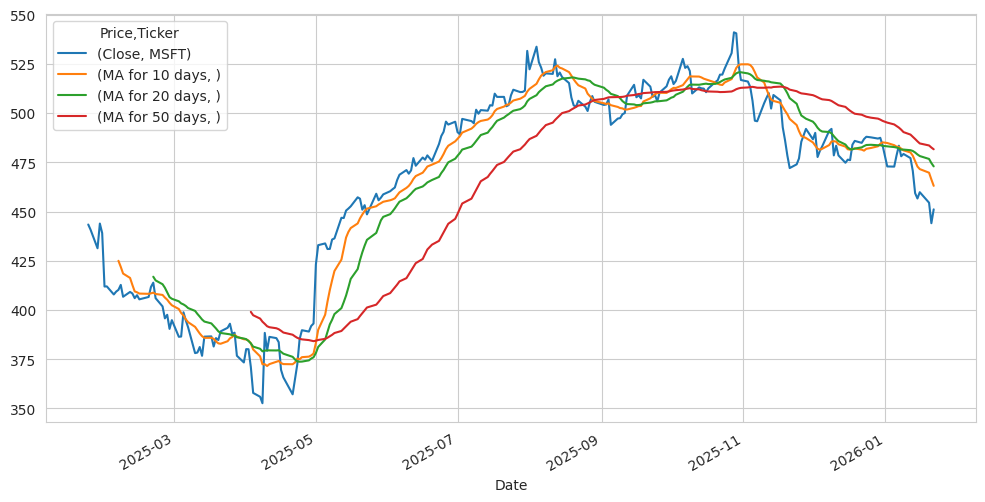

In [57]:

ma_day = [10, 20, 50]
for ma in ma_day:
    column_name = f"MA for {ma} days"
    MSFT[column_name] = MSFT['Close'].rolling(ma).mean()

MSFT[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(subplots=False, figsize=(12,6))

This chart provides a visual representation of Microsoft's (MSFT) closing prices over a one-year period, overlaid with its 10, 20, and 50-day moving averages to highlight shifting price trends and momentum.

In [111]:
print(AAPL.tail())

Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2026-01-15  258.209991  261.040009  257.049988  260.649994  39388600   
2026-01-16  255.529999  258.899994  254.929993  257.899994  72142800   
2026-01-20  246.699997  254.789993  243.419998  252.729996  80267500   
2026-01-21  247.649994  251.559998  245.179993  248.699997  54641700   
2026-01-22  248.350006  251.000000  248.149994  249.199997  39451900   

Price      MA for 10 days MA for 20 days MA for 50 days MA for {ma} days  \
Ticker                                                                     
Date                                                                       
2026-01-15            NaN            NaN            NaN              NaN   
2026-01-16            NaN            NaN            NaN              NaN   
2026-01-20            NaN            NaN   

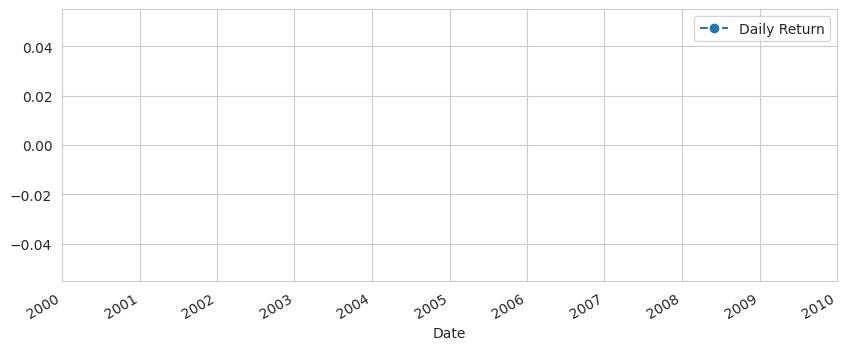

In [112]:
GOOG['Daily Return'] = GOOG['Close'].pct_change()
GOOG['Daily Return'].plot(figsize=(10,4), legend=True, linestyle='--', marker='o')
plt.show()


The above plot represents the daily return of the stock.

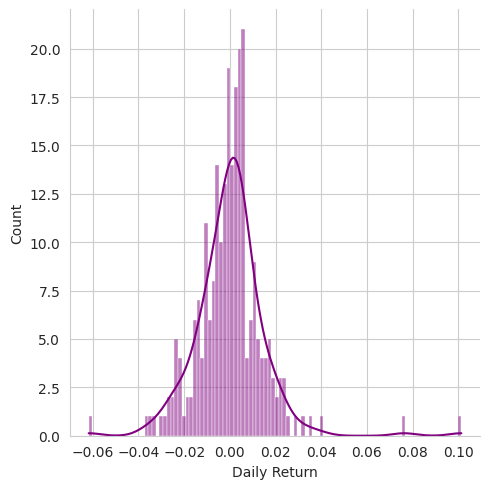

In [79]:
sns.displot(MSFT['Daily Return'].dropna(),bins=100,color='PURPLE',kde=True)

In [85]:
closing_df = pd.DataFrame({'AAPL': AAPL[('Close', 'AAPL')], 'GOOG': GOOG[('Close', 'GOOG')], 'MSFT': MSFT[('Close', 'MSFT')], 'AMZN': AMZN[('Close', 'AMZN')]})
closing_df.head()

,AAPL,GOOG,MSFT,AMZN
Date,,,,
2025-01-23,222.653015,198.806030,443.438812,235.419998
2025-01-24,221.776947,201.117020,440.808258,234.850006
2025-01-27,228.825089,193.018570,431.377808,235.419998
2025-01-28,237.187241,196.305786,443.925262,238.149994
2025-01-29,238.282303,196.415329,439.090881,237.070007


In [87]:
tech_rets=closing_df.pct_change()
tech_rets.head()

,AAPL,GOOG,MSFT,AMZN
Date,,,,
2025-01-23,NaN,NaN,NaN,NaN
2025-01-24,-0.003935,0.011624,-0.005932,-0.002421
2025-01-27,0.031780,-0.040267,-0.021394,0.002427
2025-01-28,0.036544,0.017031,0.029087,0.011596
2025-01-29,0.004617,0.000558,-0.010890,-0.004535


In [88]:
tech_rets.corr()

,AAPL,GOOG,MSFT,AMZN
AAPL,1.000000,0.504481,0.475477,0.562878
GOOG,0.504481,1.000000,0.405662,0.522626
MSFT,0.475477,0.405662,1.000000,0.577590
AMZN,0.562878,0.522626,0.577590,1.000000


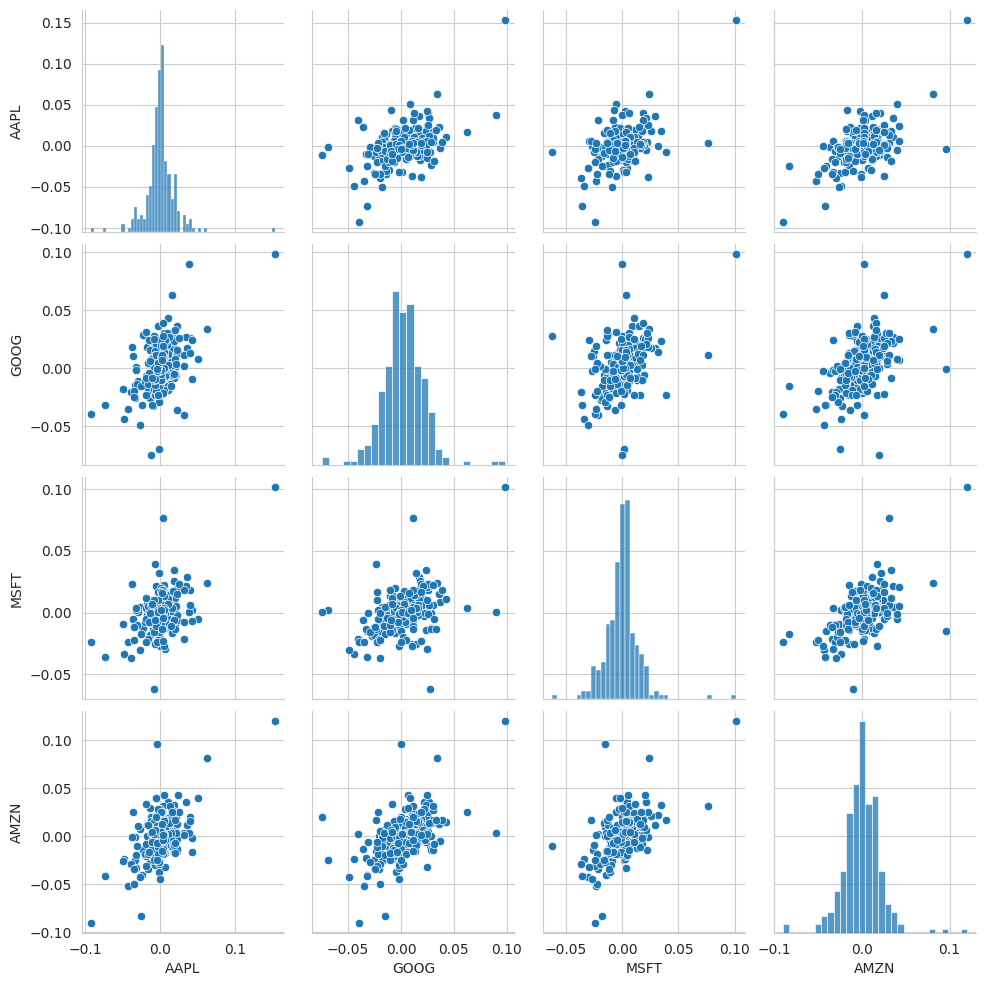

In [90]:
sns.pairplot(tech_rets.dropna())

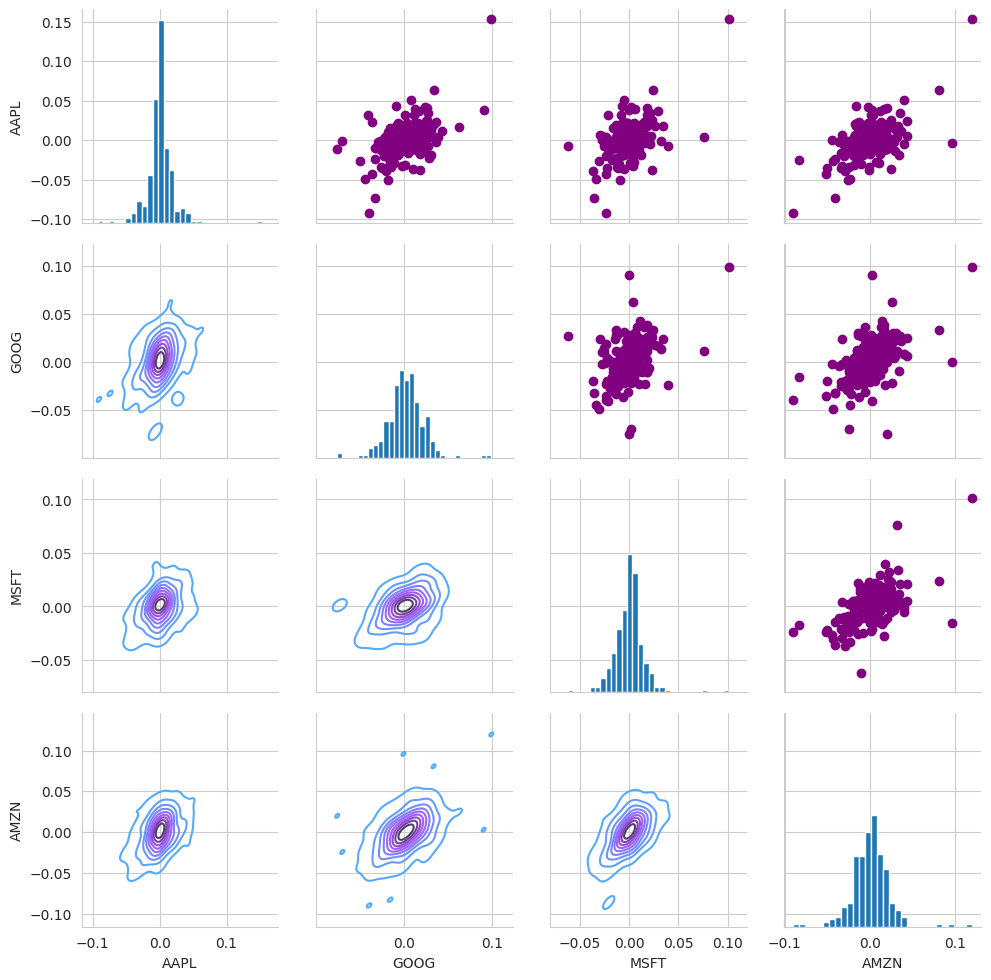

In [91]:
returns_fig = sns.PairGrid(tech_rets.dropna())
returns_fig.map_upper(plt.scatter,color='purple')   #upper triangle
returns_fig.map_lower(sns.kdeplot,cmap='cool_d')    #lower triangle
returns_fig.map_diag(plt.hist,bins=30)              #the diagonal row

While owning these four stocks feels like diversification, this visualization reveals high sector concentration. Because their movements are so tightly linked, the portfolio is highly sensitive to tech-sector shocks. To achieve true diversification, an investor would look for stocks that show a more "circular" or scattered pattern, indicating they move independently of the tech pack.

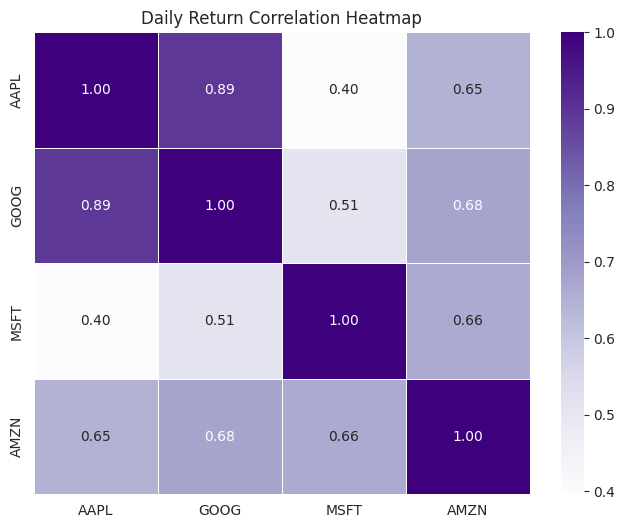

In [92]:
corr = closing_df.dropna().corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Purples', fmt=".2f", linewidths=0.5)

plt.title('Daily Return Correlation Heatmap')
plt.show()

While the scatter plots showed us the "direction" of the movement, this Heatmap provides a precise score for how closely these stocks mimic each other.

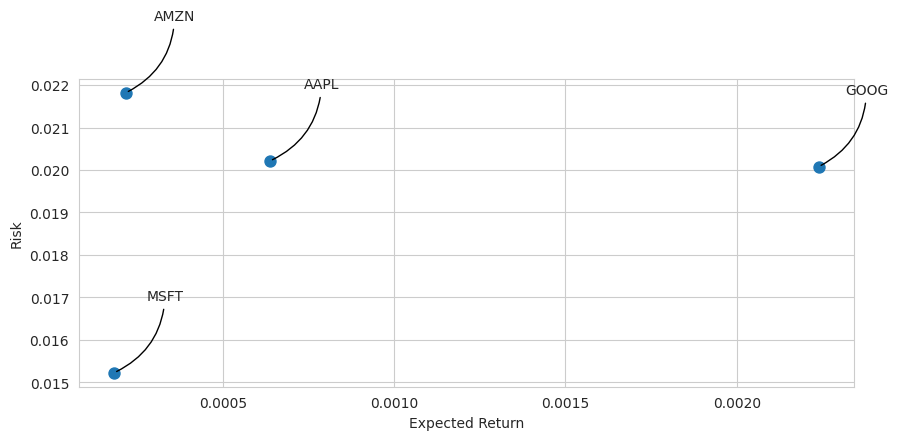

In [103]:
rets = tech_rets.dropna()
# 1. Setup the figure
plt.figure(figsize=(10, 4))
area = np.pi * 20

# 2. Create the base scatter plot
plt.scatter(rets.mean(), rets.std(), s=area)

# 3. Set the axis labels
plt.xlabel('Expected Return')
plt.ylabel('Risk')

# 4. ADD THE LABELS (Must be in the same cell!)
for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(
        label,
        xy=(x, y), xytext=(50, 50),
        textcoords='offset points', ha='right', va='bottom',
        arrowprops=dict(arrowstyle='-', color='black', connectionstyle='arc3,rad=-0.3'))

# 5. Show the final result
plt.show()

Our 'Risk vs. Return' plot shows the trade-off each stock offers: for example, MSFT provides a 'smoother' ride with lower risk, while AMZN offers higher potential growth but requires the investor to stomach much larger price swings. An ideal investor looks for stocks that are as far 'down and to the right' as possiblewhich would be in the bottom-right corner (High Return, Low Risk). Since most stocks follow a diagonal trend from bottom-left to top-right, it proves a fundamental market rule: to get higher returns (like Google), you must be willing to accept higher risk.

In [104]:
#now using monte carlo method to predict future stock behaviour
days = 365

dt = 1/days

mu = rets.mean()['GOOG']

sigma = rets.std()['GOOG']
def stock_monte_carlo(start_price,days,mu,sigma):

    price = np.zeros(days)
    price[0] = start_price

    shock = np.zeros(days)
    drift = np.zeros(days)

    for x in range(1,days):

        shock[x] = np.random.normal(loc=mu*dt,scale=sigma*np.sqrt(dt))

        drift[x] = mu * dt

        price[x] = price[x-1] + (price[x-1] * (drift[x] + shock[x]))

    return price
GOOG.head()

Price,Close,High,Low,Open,Volume,MA for {ma} days,MA for 10 days,MA for 20 days,MA for 50 days,Daily Return
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,,,,,
Date,,,,,,,,,,
2025-01-23,198.806030,201.156879,196.056739,199.204473,15170800,NaN,NaN,NaN,NaN,NaN
2025-01-24,201.117020,201.784435,199.009228,199.074982,12732400,NaN,NaN,NaN,NaN,NaN
2025-01-27,193.018570,197.899562,191.952712,193.436939,24970200,NaN,NaN,NaN,NaN,NaN
2025-01-28,196.305786,196.465154,191.863075,193.895157,15939200,NaN,NaN,NaN,NaN,NaN
2025-01-29,196.415329,197.690379,194.433056,196.604595,12287800,NaN,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'Monte Carlo Analysis for Google')

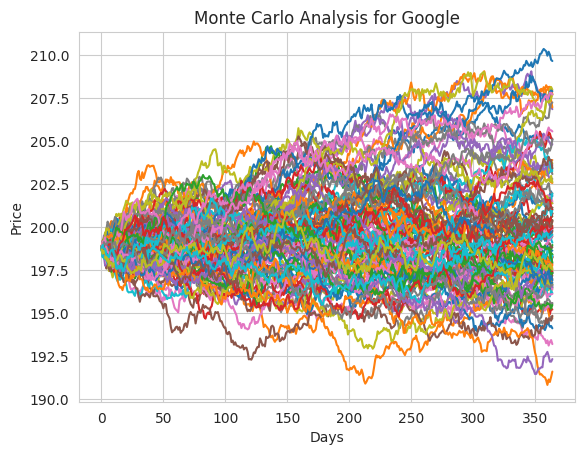

In [106]:
start_price = 198.8

for run in range(100):   # do simulation for 100 times
    plt.plot(stock_monte_carlo(start_price,days,mu,sigma))

plt.xlabel('Days')
plt.ylabel('Price')
plt.title('Monte Carlo Analysis for Google')

Text(0.5, 1.0, 'Final price distribution for Google Stock after 365 days')

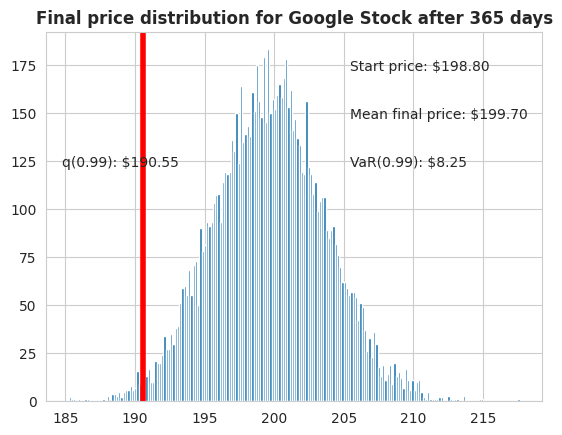

In [113]:
runs=10000

simulations = np.zeros(runs)

for run in range(runs):
    simulations[run] = stock_monte_carlo(start_price,days,mu,sigma)[days-1]
q = np.percentile(simulations,1)

plt.hist(simulations,bins=200)

# Starting Price
plt.figtext(0.6,0.8, s="Start price: $%.2f" %start_price)

# Mean Ending Price
plt.figtext(0.6,0.7, "Mean final price: $%.2f" % simulations.mean())

#Variance of the price (within 99% confidence interval)
plt.figtext(0.6,0.6, "VaR(0.99): $%.2f" % (start_price - q,))

# Display 1% quantile
plt.figtext(0.15,0.6, "q(0.99): $%.2f" % q)

# Plot a line at the 1% quantile result
plt.axvline(x=q, linewidth=4,color='r')

# Title
plt.title(u"Final price distribution for Google Stock after %s days" %days, weight='bold')